# Phase 4 — FMPE, Step 2: Heston with $V = (v_0, \theta)$

**Requires `heston_core.py` in the same directory.**

### Where this sits

| Step | simulator $F$ | $V$ | referee |
|---|---|---|---|
| 1 (done) | $V + W$ | 1-D | **analytic posterior** (closed form) |
| **2 (here)** | **Heston FTE Euler MC** | **2-D: $(v_0, \theta)$** | **semi-analytic Fourier pricer** (validates $F$, not the posterior) |
| 3 | Heston MC | 5-D: $(\kappa,\theta,\xi,\rho,v_0)$ | none |
| 4 | — | deploy on real NIFTY surface | none; misspecified |

**Read this before running.** In Step 1 the referee checked the **posterior**. Here the referee only
checks the **simulator**. There is no closed-form posterior for Heston, so from this step onward
**calibration (Metric B) is the entire correctness argument.** That is why Step 1 existed: it is the
only place we could ever verify the posterior machinery directly.

### The fork you should be able to defend

Heston has a closed-form characteristic function, so prices *can* be computed exactly by Fourier
integration. With that pricer, $F(V)$ is deterministic, $W$ does not exist, the likelihood
$p(X \mid V) = \mathcal{N}(X; F(V), \sigma^2 I)$ is **tractable**, and MCMC would work.

So: **for Heston alone, SBI is not strictly necessary.** We use the MC simulator deliberately, because
(a) it matches the Phase-3 numerical model, (b) it makes $W$ a real nuisance and the likelihood
genuinely intractable, and (c) Heston is a **testbed with ground truth** — the payoff is models with
*no* analytic pricer (rough Bergomi, local-stochastic vol, jumps). Amortisation is a win either way:
one training run, then any surface in milliseconds.

Expect this exact question from your professor. The Fourier pricer is kept in the notebook as the
honest answer to it.

## 1. What changes from Step 1 — and what does not

**Unchanged (literally the same code):** the prior $\to$ simulator $\to$ joint-samples logic, the
logit transform, the CFM-OT loss, the ODE sampler, both metrics.

**Changed:**

| | Step 1 | Step 2 |
|---|---|---|
| $V$ | 1-D | 2-D $(v_0, \theta)$; $\kappa,\xi,\rho$ **frozen** |
| $X$ | 5 numbers | IV surface, $6 \text{ maturities} \times 5 \text{ strikes} = 30$ numbers |
| $W$ | a scalar draw | the **Brownian paths** |
| cost of one $F$ | microseconds | Monte-Carlo — the binding constraint |
| network | concat $X$ | small **encoder** on the 30-D surface, then concat |
| diagnostics | — | posterior **correlation**; $\kappa$–$\theta$-style ridges are the thing to look for |

**Why $(v_0, \theta)$ first.** They are the two variance-level parameters and they are known to trade
off: $v_0$ sets the short end, $\theta$ the long end, and in between they are partially
interchangeable. A 2-D posterior can be **plotted and eyeballed**. If we cannot get 2-D right, 5-D is
hopeless — and unlike 5-D, we would never know.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time

from heston_core import (heston_surface, simulate_heston, make_strikes,
                         heston_call_analytic, implied_vol)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
rng = np.random.default_rng(SEED)

print("torch:", torch.__version__, "| device:", device)
if device.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.13.0+cu130 | device: cuda
gpu: NVIDIA GeForce RTX 5070 Ti Laptop GPU


## 2. Configuration

**The three `*_FIX` values below are PLACEHOLDERS.** Replace them with the Phase-3 calibrated
$\kappa, \xi, \rho$ before you present anything. `RHO_FIX = -0.70` is the Phase-3 *starting* value,
not the fitted $-0.51$ — that fit is the one whose skew moved the wrong way against an obviously
skewed market, so it is not trustworthy as a frozen constant.

**On the strike grid.** Strikes are set in **ATM standard deviations**, $K = F_0 e^{z\,\sigma_{\rm ref}\sqrt{T}}$,
not fixed moneyness. Fixed moneyness puts short maturities several $\sigma$ out-of-the-money, the MC
price degenerates, and implied vol cannot be inverted. `SIG_REF = 0.15` matches the Phase-3 market ATM
(13–16%); with `Z = ±1.5` the worst-case cell is ~2.25$\sigma$ out at *every* maturity.

In [ ]:
# ---------------- Market / grid ----------------
F0      = 1.0                                          # work on the normalised forward
T_GRID  = [0.019, 0.036, 0.077, 0.153, 0.249, 0.403]   # Phase-3 maturities
Z_GRID  = [-1.5, -0.75, 0.0, 0.75, 1.5]                # strikes in ATM standard deviations
SIG_REF = 0.15                                         # reference vol for the sqrt-T strike scaling
N_T, N_Z = len(T_GRID), len(Z_GRID)
DIM_X   = N_T * N_Z                                    # 30: the flattened surface

# ---------------- FROZEN Heston parameters -- PLACEHOLDERS, REPLACE ----------------
KAPPA_FIX = 2.00     # <-- Phase-3 calibrated kappa
XI_FIX    = 0.50     # <-- Phase-3 calibrated xi
RHO_FIX   = -0.70    # <-- Phase-3 calibrated rho (NOT the -0.51 fit; see markdown above)

# ---------------- Inferred parameters V = (v0, theta) ----------------
V_LO = np.array([0.01, 0.01])    # v0, theta   -> vol in [0.10, 0.30]
V_HI = np.array([0.09, 0.09])
V_NAMES = [r"$v_0$", r"$\theta$"]
DIM_V = 2

# ---------------- Simulator (n_paths is PART OF THE MODEL) ----------------
N_PATHS = 32_768     # sigma_MC ~ 0.0011 vol pts at this count (measured vs Fourier referee)
N_STEPS = 400
SIGMA_OBS = 0.005    # E: observation noise on IV, same order as sigma_MC -> W is a real nuisance
SIM_CHUNK = 128      # parameter draws per GPU batch; lower this if you hit OOM

# ---------------- Training ----------------
N_SIM  = 20_000      # simulation budget. THE expensive number. Time it before launching (below).
BATCH  = 2048
STEPS  = 8_000
LR     = 1e-3
SIGMA_MIN = 1e-3

# ---------------- Evaluation ----------------
M_EVAL, L_EVAL = 2000, 500   # held-out truths, posterior samples each. Cheap: NO simulator calls.

print(f"X: {N_T} maturities x {N_Z} strikes = {DIM_X}-D surface")
print(f"V: {DIM_V}-D, v0 in [{V_LO[0]}, {V_HI[0]}], theta in [{V_LO[1]}, {V_HI[1]}]")
print(f"   -> spot vol in [{np.sqrt(V_LO[0]):.2f}, {np.sqrt(V_HI[0]):.2f}]")
print(f"FROZEN: kappa={KAPPA_FIX}, xi={XI_FIX}, rho={RHO_FIX}   <-- PLACEHOLDERS")
feller = 2 * KAPPA_FIX * np.array([V_LO[1], V_HI[1]]) - XI_FIX**2
print(f"Feller 2*kappa*theta - xi^2 over the prior: [{feller[0]:+.3f}, {feller[1]:+.3f}]"
      f"  ({'spans both signs' if feller[0]*feller[1] < 0 else 'one sign'}) -- not enforced, by design")

X: 6 maturities x 5 strikes = 30-D surface
V: 2-D, v0 in [0.01, 0.09], theta in [0.01, 0.09]
   -> spot vol in [0.10, 0.30]
FROZEN: kappa=2.0, xi=0.5, rho=-0.7   <-- PLACEHOLDERS
Feller 2*kappa*theta - xi^2 over the prior: [-0.210, +0.110]  (spans both signs) -- not enforced, by design


## 3. Check the simulator against the Fourier referee

Before spending the simulation budget, confirm the MC surface is unbiased. We compare 12 independent
MC runs at one parameter value against the semi-analytic price, and measure two different things:

- $\sigma_{\rm MC}$ — the **run-to-run spread at fixed $V$**. This *is* the nuisance $W$, quantified.
  It must scale as $1/\sqrt{n_{\rm paths}}$.
- **bias** — the mean MC surface minus the exact one. This is Euler discretisation error. It must be
  roughly *invariant* to `n_paths`.

Expected (measured previously with this grid): $\sigma_{\rm MC} \approx 0.0011$ and
bias $\approx 0.0006$ at 32k paths.

**Why the bias is tolerable here but not in Step 4.** Training and deployment use the *same*
simulator, so the flow simply learns the biased $F$ and the offset cancels. Against the **real** NIFTY
surface it does not cancel — it becomes misspecification, on top of the Phase-3 finding that
one-factor Heston cannot span 0.02y–0.40y.

In [3]:
V_probe = np.array([[KAPPA_FIX, 0.04, XI_FIX, RHO_FIX, 0.04]])   # (kappa, theta, xi, rho, v0)
Vt_probe = torch.tensor(V_probe, dtype=torch.float32, device=device)

# --- exact surface from the Fourier pricer ---
Ks = make_strikes(T_GRID, Z_GRID, F0, SIG_REF)
an = np.zeros((N_T, N_Z))
for i, T in enumerate(T_GRID):
    for j, K in enumerate(Ks[i]):
        p = heston_call_analytic(float(K), T, KAPPA_FIX, V_probe[0,1], XI_FIX, RHO_FIX, V_probe[0,4], F0)
        an[i, j] = implied_vol(torch.tensor([[p]]), torch.tensor([[F0]]),
                               torch.tensor([[float(K)]]), torch.tensor([[T]])).item()

# --- 12 MC repeats at two path counts ---
for n_paths in [N_PATHS // 4, N_PATHS]:
    reps = np.stack([heston_surface(Vt_probe, T_GRID, Z_GRID, F0, n_paths, N_STEPS,
                                    device, SIG_REF)[0].cpu().numpy() for _ in range(12)])
    sd, bias = reps.std(0), np.abs(reps.mean(0) - an)
    print(f"=== {n_paths:6d} paths ===  sigma_MC mean {sd.mean():.5f} max {sd.max():.5f}"
          f" | |bias| mean {bias.mean():.5f} max {bias.max():.5f}")

print("\nPASS if: sigma_MC roughly halves when paths x4, and |bias| stays flat.")
print("\nExact surface (rows = maturities, cols = z):\n", np.round(an, 4))

===   8192 paths ===  sigma_MC mean 0.00186 max 0.00335 | |bias| mean 0.00118 max 0.00207
===  32768 paths ===  sigma_MC mean 0.00106 max 0.00174 | |bias| mean 0.00066 max 0.00164

PASS if: sigma_MC roughly halves when paths x4, and |bias| stays flat.

Exact surface (rows = maturities, cols = z):
 [[0.2122 0.2057 0.199  0.1922 0.1853]
 [0.216  0.2072 0.1981 0.1887 0.1794]
 [0.2214 0.2091 0.1961 0.1825 0.1697]
 [0.2266 0.2104 0.1927 0.1744 0.1592]
 [0.2297 0.2105 0.1893 0.1677 0.1524]
 [0.2317 0.2097 0.1854 0.1616 0.147 ]]


## 4. Budget the simulation before you spend it

`N_SIM = 20_000` Monte-Carlo surfaces is the expensive step and the one thing that does not amortise.
Time a small batch and extrapolate **before** launching the full run. If the estimate is unacceptable,
your levers in order of preference:

1. lower `N_SIM` (costs posterior sharpness),
2. lower `N_PATHS` (raises $\sigma_{\rm MC}$ — legitimate, but it must then match at deployment),
3. lower `N_STEPS` (raises bias — the least attractive, since bias does not cancel in Step 4).

In [4]:
V_time = np.column_stack([np.full(SIM_CHUNK, KAPPA_FIX),
                          rng.uniform(V_LO[1], V_HI[1], SIM_CHUNK),
                          np.full(SIM_CHUNK, XI_FIX),
                          np.full(SIM_CHUNK, RHO_FIX),
                          rng.uniform(V_LO[0], V_HI[0], SIM_CHUNK)])
t0 = time.time()
_ = simulate_heston(V_time, T_GRID, Z_GRID, F0, N_PATHS, N_STEPS, SIGMA_OBS,
                    device, rng, sig_ref=SIG_REF, chunk=SIM_CHUNK)
dt = time.time() - t0
print(f"{SIM_CHUNK} surfaces in {dt:.1f}s -> {dt/SIM_CHUNK*1000:.1f} ms each")
print(f"ESTIMATE for N_SIM={N_SIM:,}: {dt/SIM_CHUNK*N_SIM/60:.1f} min")
print(f"(+ eval set of {M_EVAL:,}: {dt/SIM_CHUNK*M_EVAL/60:.1f} min)")

128 surfaces in 0.7s -> 5.3 ms each
ESTIMATE for N_SIM=20,000: 1.8 min
(+ eval set of 2,000: 0.2 min)


## 5. Prior and the simulation run

$$v_0 \sim U(0.01, 0.09), \qquad \theta \sim U(0.01, 0.09)$$

**Feller is deliberately not enforced.** Rejecting draws with $2\kappa\theta \le \xi^2$ would make the
training prior differ from the prior we claim at deployment, which silently biases every posterior.
Full-truncation Euler handles $v<0$ by construction. We *record* the Feller ratio and check afterwards
whether the posterior cares.

The logit transform is unchanged from Step 1, applied **per component** — each parameter gets its own
box.

In [5]:
def sample_prior(n, rng):
    """Draw (v0, theta) from the prior -> (n, 2)."""
    return rng.uniform(V_LO, V_HI, size=(n, DIM_V))

def to_full_V(V2):
    """(n, 2) inferred (v0, theta) -> (n, 5) full (kappa, theta, xi, rho, v0) for the simulator."""
    n = V2.shape[0]
    return np.column_stack([np.full(n, KAPPA_FIX), V2[:, 1],
                            np.full(n, XI_FIX), np.full(n, RHO_FIX), V2[:, 0]])

def to_unconstrained(v):
    """(n, 2) in the box -> R^2. Per-component logit."""
    u = np.clip((v - V_LO) / (V_HI - V_LO), 1e-6, 1 - 1e-6)
    return np.log(u / (1 - u))

def to_constrained(vt):
    """R^2 -> the box. Torch; applied to the flow's output."""
    lo = torch.tensor(V_LO, dtype=torch.float32, device=vt.device)
    hi = torch.tensor(V_HI, dtype=torch.float32, device=vt.device)
    return lo + (hi - lo) * torch.sigmoid(vt)

In [6]:
# ============ THE EXPENSIVE CELL ============
t0 = time.time()
V_train = sample_prior(N_SIM, rng)
X_train = simulate_heston(to_full_V(V_train), T_GRID, Z_GRID, F0, N_PATHS, N_STEPS,
                          SIGMA_OBS, device, rng, sig_ref=SIG_REF, chunk=SIM_CHUNK)
print(f"training set: {X_train.shape} in {(time.time()-t0)/60:.1f} min")

# held-out pairs for the validation CFM loss (diagnoses overfitting to a finite N_SIM)
V_val = sample_prior(4_000, rng)
X_val = simulate_heston(to_full_V(V_val), T_GRID, Z_GRID, F0, N_PATHS, N_STEPS,
                        SIGMA_OBS, device, rng, sig_ref=SIG_REF, chunk=SIM_CHUNK)

assert np.isfinite(X_train).all(), "non-finite IV -- inversion failed somewhere; check the strike grid"
print(f"IV range: [{X_train.min():.4f}, {X_train.max():.4f}]  (sane: no cell near 0)")

# ---- preprocessing: fit on train, reuse VERBATIM at deployment ----
X_MEAN, X_STD = X_train.mean(), X_train.std()

V_tilde     = torch.tensor(to_unconstrained(V_train), dtype=torch.float32, device=device)
X_cond      = torch.tensor((X_train - X_MEAN) / X_STD, dtype=torch.float32, device=device)
V_tilde_val = torch.tensor(to_unconstrained(V_val),   dtype=torch.float32, device=device)
X_cond_val  = torch.tensor((X_val  - X_MEAN) / X_STD, dtype=torch.float32, device=device)

print(f"flow state {tuple(V_tilde.shape)} | context {tuple(X_cond.shape)}")
print(f"X standardisation: mean={X_MEAN:.4f}, std={X_STD:.4f}")

training set: (20000, 30) in 2.2 min
IV range: [0.0660, 0.3252]  (sane: no cell near 0)
flow state (20000, 2) | context (20000, 30)
X standardisation: mean=0.2132, std=0.0531


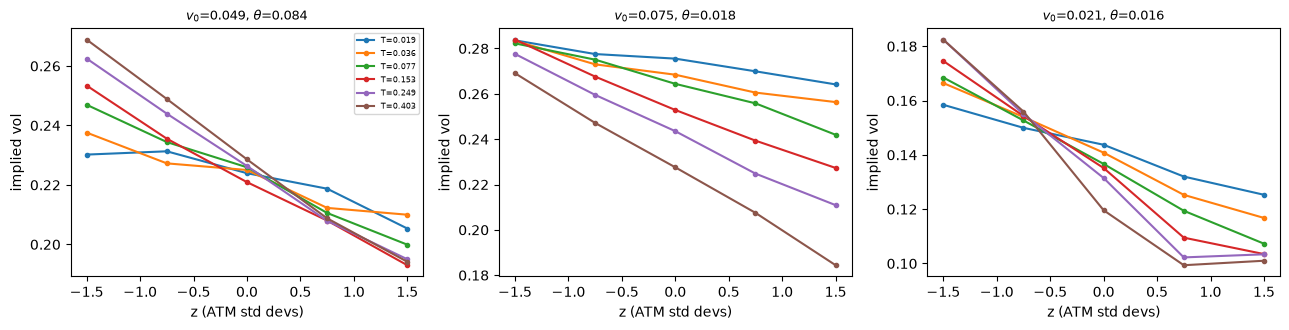

In [7]:
# Look at a few surfaces: they should show a downward skew (rho < 0) and a term structure.
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for a, i in zip(ax, range(3)):
    S = X_train[i].reshape(N_T, N_Z)
    for j, T in enumerate(T_GRID):
        a.plot(Z_GRID, S[j], "o-", ms=3, label=f"T={T}")
    a.set_xlabel("z (ATM std devs)"); a.set_ylabel("implied vol")
    a.set_title(f"$v_0$={V_train[i,0]:.3f}, $\\theta$={V_train[i,1]:.3f}", fontsize=9)
ax[0].legend(fontsize=6)
plt.tight_layout(); plt.show()

## 6. The network

One structural change from Step 1: the context is a 30-D surface rather than 5 loose numbers, so it
goes through a small **encoder** first. Everything else is identical.

$$v_\theta\big(\tilde{V}_t,\ t,\ \mathrm{Enc}(X)\big), \qquad \tilde{V}_t \in \mathbb{R}^2$$

The encoder is not decoration: it is the piece that scales: in Step 3 the flow becomes 5-D but the
surface stays 30-D, and later a per-maturity encoder can exploit the smile structure. $X$ is still
never transported by the flow: it selects *which* posterior to move towards.

In [8]:
class VelocityNet(nn.Module):
    """Conditional velocity field v_theta(V_t, t, Enc(X)) for V in R^2, X the 30-D surface."""
    def __init__(self, dim_v=DIM_V, dim_x=DIM_X, d_emb=128, hidden=256, depth=4):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(dim_x, d_emb), nn.SiLU(),
            nn.Linear(d_emb, d_emb), nn.SiLU())
        layers, d = [], dim_v + 1 + d_emb
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.SiLU()]; d = hidden
        layers += [nn.Linear(hidden, dim_v)]
        self.net = nn.Sequential(*layers)

    def forward(self, v_t, t, x):
        return self.net(torch.cat([v_t, t, self.enc(x)], dim=-1))


net = VelocityNet().to(device)
print("trainable parameters:", sum(p.numel() for p in net.parameters()))

trainable parameters: 252162


## 7. Training

The CFM-OT loss, verbatim from Step 1 — only the dimensions changed. The loss again **plateaus above
zero**: many $(\tilde V_0, \tilde V_1)$ pairs give the same $\tilde V_t$, so the best possible
prediction is the conditional average, and the residual variance is irreducible.

The **validation loss** is the cell that matters. If train keeps falling while val flattens, you are
memorising a finite `N_SIM` and the posteriors will be over-confident — the fix is more simulations,
not more steps.

step   2000 | train 0.3126 | val 0.3030
step   4000 | train 0.2748 | val 0.2733
step   6000 | train 0.2644 | val 0.2663
step   8000 | train 0.2602 | val 0.2691
step  10000 | train 0.2568 | val 0.2515
step  12000 | train 0.2539 | val 0.2618
step  14000 | train 0.2515 | val 0.2544
step  16000 | train 0.2482 | val 0.2496
step  18000 | train 0.2502 | val 0.2510
step  20000 | train 0.2464 | val 0.2538
train time 0.6 min


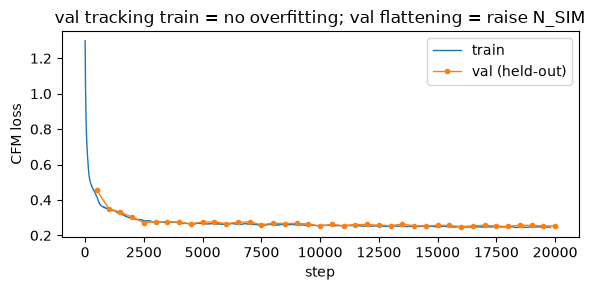

In [9]:
opt = torch.optim.Adam(net.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=STEPS)

def cfm_loss(v1, xc):
    v0 = torch.randn_like(v1)
    t  = torch.rand(v1.shape[0], 1, device=device)
    v_t = (1 - (1 - SIGMA_MIN) * t) * v0 + t * v1      # OT interpolant
    u   = v1 - (1 - SIGMA_MIN) * v0                    # target velocity
    return ((net(v_t, t, xc) - u) ** 2).mean()

@torch.no_grad()
def val_loss(n_rep=8):
    net.eval()
    out = float(np.mean([cfm_loss(V_tilde_val, X_cond_val).item() for _ in range(n_rep)]))
    net.train(); return out

t0, tr_hist, va_hist = time.time(), [], []
for step in range(1, STEPS + 1):
    idx = torch.randint(0, N_SIM, (BATCH,), device=device)
    loss = cfm_loss(V_tilde[idx], X_cond[idx])
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    tr_hist.append(loss.item())
    if step % 500 == 0:
        va_hist.append((step, val_loss()))
        if step % 2000 == 0:
            print(f"step {step:6d} | train {np.mean(tr_hist[-500:]):.4f} | val {va_hist[-1][1]:.4f}")
print(f"train time {(time.time()-t0)/60:.1f} min")

plt.figure(figsize=(6, 3))
plt.plot(np.convolve(tr_hist, np.ones(200)/200, mode="valid"), lw=1, label="train")
plt.plot(*zip(*va_hist), "o-", ms=3, lw=1, label="val (held-out)")
plt.xlabel("step"); plt.ylabel("CFM loss"); plt.legend()
plt.title("val tracking train = no overfitting; val flattening = raise N_SIM")
plt.tight_layout(); plt.show()

In [10]:
@torch.no_grad()
def sample_posterior(X_obs, n_samples, nfe=100, chunk=200_000):
    """
    X_obs: (M, DIM_X) raw surfaces -> (M, n_samples, DIM_V) posterior draws in the ORIGINAL box.
    All M*n ODEs solved in parallel, chunked for VRAM. No simulator calls: this is the amortised part.
    """
    net.eval()
    X_obs = np.atleast_2d(X_obs); M = X_obs.shape[0]
    xc_all = torch.tensor((X_obs - X_MEAN) / X_STD, dtype=torch.float32, device=device)
    xc_all = xc_all.repeat_interleave(n_samples, dim=0)          # [x0]*n, [x1]*n, ...
    out, dt = [], 1.0 / nfe
    for s in range(0, xc_all.shape[0], chunk):
        xc = xc_all[s:s+chunk]
        v = torch.randn(xc.shape[0], DIM_V, device=device)
        for k in range(nfe):                                      # midpoint (RK2)
            t  = torch.full((xc.shape[0], 1), k * dt, device=device)
            k1 = net(v, t, xc)
            k2 = net(v + 0.5 * dt * k1, t + 0.5 * dt, xc)
            v  = v + dt * k2
        out.append(to_constrained(v).cpu().numpy())
    net.train()
    return np.concatenate(out, axis=0).reshape(M, n_samples, DIM_V)

# Sanity: repeat_interleave must pair each surface with its own block of samples.
# If this errors, the reshape above is scrambling rows.
_chk = sample_posterior(X_train[:2], 64)
assert _chk.shape == (2, 64, DIM_V), _chk.shape
print("sampler OK:", _chk.shape)

sampler OK: (2, 64, 2)


## 8. The 2-D posterior

The plot Step 1 could not produce. For one held-out truth we show the joint posterior plus both
marginals.

**What to look for — this is the actual scientific content of Step 2:**

- **A tilted, elongated cloud** = the $v_0$–$\theta$ ridge. Expected, and it is the *point*: a
  point-estimate optimiser (Phase 3) would have picked one spot on this ridge and reported it with
  false confidence. The posterior shows the whole thing.
- **A narrow, round, axis-aligned cloud** = suspicious. These two parameters should not be cleanly
  separable from a single surface. If you see this, doubt the pipeline before believing the result.
- **Mass piled against a box edge** = the prior is too tight; widen it and re-run.
- The truth $V^\star$ should sit **inside the bulk, not at the centre** — it is a draw, not the mean.

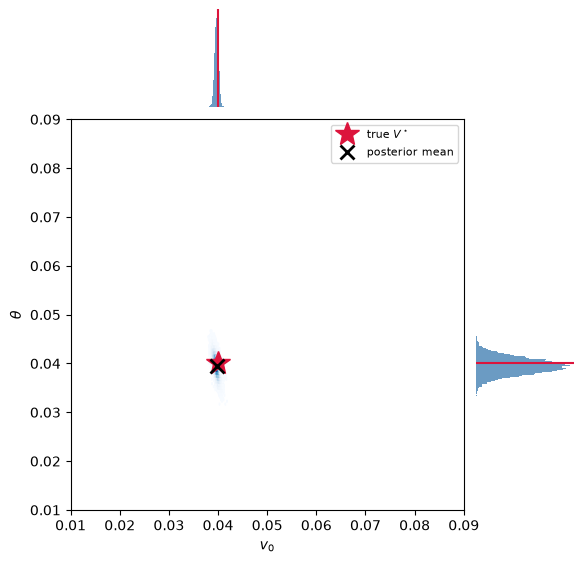

   $v_0$: true 0.0400 | post mean 0.0397 +/- 0.0004
$\theta$: true 0.0400 | post mean 0.0395 +/- 0.0017

posterior corr(v0, theta) = -0.604
|corr| > 0.5 -> a real ridge: the surface constrains a COMBINATION, not each separately.


In [11]:
rng_test = np.random.default_rng(0)                    # separate stream: held-out
V_star = np.array([[0.04, 0.04]])                      # a truth to inspect
X_x = simulate_heston(to_full_V(V_star), T_GRID, Z_GRID, F0, N_PATHS, N_STEPS,
                      SIGMA_OBS, device, rng_test, sig_ref=SIG_REF)
post = sample_posterior(X_x, 20_000)[0]                # (20000, 2)

fig = plt.figure(figsize=(6.5, 6.5))
gs = fig.add_gridspec(2, 2, width_ratios=(4,1), height_ratios=(1,4), wspace=0.05, hspace=0.05)
axj = fig.add_subplot(gs[1,0]); axx = fig.add_subplot(gs[0,0], sharex=axj)
axy = fig.add_subplot(gs[1,1], sharey=axj)

axj.hexbin(post[:,0], post[:,1], gridsize=45, cmap="Blues", mincnt=1)
axj.plot(*V_star[0], "*", color="crimson", ms=18, label=r"true $V^\star$")
axj.plot(post[:,0].mean(), post[:,1].mean(), "x", color="k", ms=10, mew=2, label="posterior mean")
axj.set_xlabel(V_NAMES[0]); axj.set_ylabel(V_NAMES[1]); axj.legend(fontsize=8)
axj.set_xlim(V_LO[0], V_HI[0]); axj.set_ylim(V_LO[1], V_HI[1])

axx.hist(post[:,0], bins=70, density=True, color="steelblue", alpha=.8)
axx.axvline(V_star[0,0], color="crimson"); axx.axis("off")
axy.hist(post[:,1], bins=70, density=True, color="steelblue", alpha=.8, orientation="horizontal")
axy.axhline(V_star[0,1], color="crimson"); axy.axis("off")
plt.show()

corr = np.corrcoef(post.T)[0,1]
for d in range(DIM_V):
    print(f"{V_NAMES[d]:>8s}: true {V_star[0,d]:.4f} | post mean {post[:,d].mean():.4f}"
          f" +/- {post[:,d].std():.4f}")
print(f"\nposterior corr(v0, theta) = {corr:+.3f}")
print("|corr| > 0.5 -> a real ridge: the surface constrains a COMBINATION, not each separately.")

## 9. Both metrics

Same two as Step 1, now per-component. **Report z-scores, not bare numbers.** With $M$ held-out
truths, coverage has standard error $\sqrt{0.9 \cdot 0.1 / M}$ — at $M=500$ that is $\pm 0.013$, which
cannot distinguish 0.892 from 0.900. Chasing that difference is chasing noise. At $M=2000$ the
resolution is ~0.007.

$|z| < 2$ = consistent with calibrated.

**Metric A will look worse than in Step 1, and that is the expected result, not a failure.** The
$v_0$–$\theta$ ridge means the data genuinely cannot pin each parameter down separately. Metric A
cannot distinguish "model is broken" from "data is uninformative". Metric B can. That is the whole
argument for running both — and from here on, with no analytic posterior, Metric B is the only
correctness evidence you have.

=== Metric A: distance to truth (per component) ===
            single  post.mean  post.std   ratio  (prior width)
   $v_0$   0.00055    0.00038   0.00048   1.448   (0.080)   -> post.mean err = 0.5% of prior
$\theta$   0.00222    0.00154   0.00195   1.439   (0.080)   -> post.mean err = 1.9% of prior
  ratio single/mean: theory ~1.414

=== Metric B: calibration (the correctness argument) ===
   $v_0$ coverage 0.8975 (z=-0.37) | SBC rank  245.7/250 (z=-1.33)
$\theta$ coverage 0.8985 (z=-0.22) | SBC rank  255.1/250 (z=+1.59)
  |z| < 2 -> consistent with calibrated


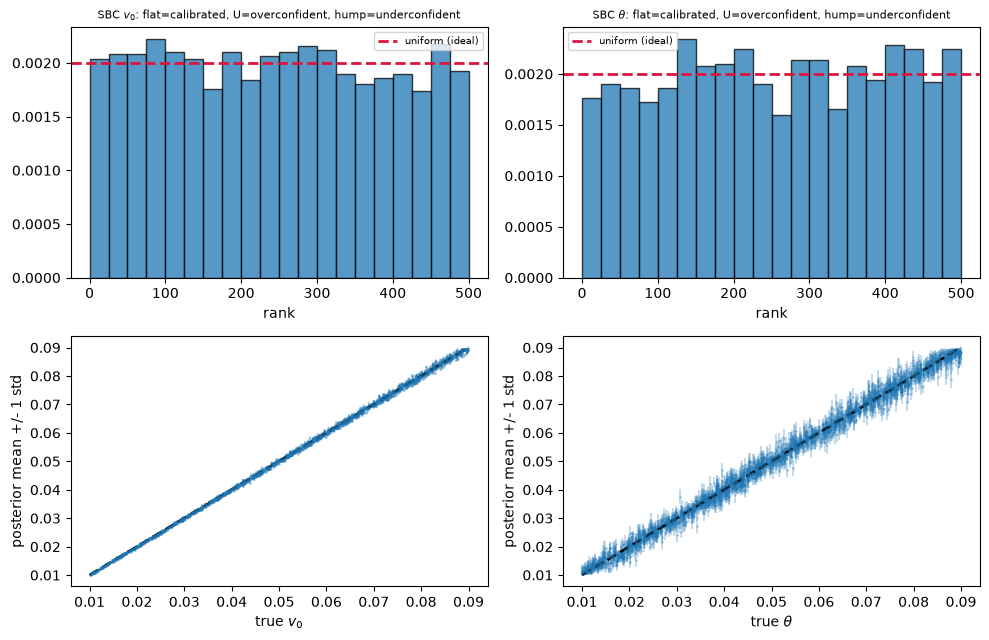


posterior corr(v0, theta): mean -0.582 | 5-95% [-0.671, -0.441]


In [12]:
V_true = sample_prior(M_EVAL, rng_test)
X_test = simulate_heston(to_full_V(V_true), T_GRID, Z_GRID, F0, N_PATHS, N_STEPS,
                         SIGMA_OBS, device, rng_test, sig_ref=SIG_REF, chunk=SIM_CHUNK)
posts = sample_posterior(X_test, L_EVAL)               # (M, L, 2)

print("=== Metric A: distance to truth (per component) ===")
print(f"{'':>8s} {'single':>9s} {'post.mean':>10s} {'post.std':>9s} {'ratio':>7s}  (prior width)")
for d in range(DIM_V):
    es = np.abs(posts[:,0,d] - V_true[:,d]).mean()
    em = np.abs(posts[:,:,d].mean(1) - V_true[:,d]).mean()
    sd = posts[:,:,d].std(1).mean()
    print(f"{V_NAMES[d]:>8s} {es:9.5f} {em:10.5f} {sd:9.5f} {es/em:7.3f}"
          f"   ({V_HI[d]-V_LO[d]:.3f})   -> post.mean err = {em/(V_HI[d]-V_LO[d])*100:.1f}% of prior")
print("  ratio single/mean: theory ~1.414")

print("\n=== Metric B: calibration (the correctness argument) ===")
se_c = np.sqrt(0.9 * 0.1 / M_EVAL)
se_r = (L_EVAL / np.sqrt(12)) / np.sqrt(M_EVAL)
for d in range(DIM_V):
    lo, hi = np.percentile(posts[:,:,d], 5, axis=1), np.percentile(posts[:,:,d], 95, axis=1)
    cov = np.mean((lo <= V_true[:,d]) & (V_true[:,d] <= hi))
    rk  = (posts[:,:,d] < V_true[:,d,None]).sum(1)
    print(f"{V_NAMES[d]:>8s} coverage {cov:.4f} (z={(cov-0.9)/se_c:+5.2f}) | "
          f"SBC rank {rk.mean():6.1f}/{L_EVAL/2:.0f} (z={(rk.mean()-L_EVAL/2)/se_r:+5.2f})")
print("  |z| < 2 -> consistent with calibrated")

fig, ax = plt.subplots(2, 2, figsize=(10, 6.5))
for d in range(DIM_V):
    rk = (posts[:,:,d] < V_true[:,d,None]).sum(1)
    ax[0,d].hist(rk, bins=20, range=(0, L_EVAL), density=True, alpha=.75, edgecolor="k")
    ax[0,d].axhline(1.0/L_EVAL, color="crimson", ls="--", lw=2, label="uniform (ideal)")
    ax[0,d].set_title(f"SBC {V_NAMES[d]}: flat=calibrated, U=overconfident, hump=underconfident",
                      fontsize=8)
    ax[0,d].set_xlabel("rank"); ax[0,d].legend(fontsize=7)

    ax[1,d].errorbar(V_true[:,d], posts[:,:,d].mean(1), yerr=posts[:,:,d].std(1),
                     fmt=".", alpha=.25, ms=2)
    ax[1,d].plot([V_LO[d], V_HI[d]], [V_LO[d], V_HI[d]], "k--", lw=2)
    ax[1,d].set_xlabel(f"true {V_NAMES[d]}"); ax[1,d].set_ylabel("posterior mean +/- 1 std")
plt.tight_layout(); plt.show()

# Does the ridge appear across the whole prior, or only locally?
corrs = np.array([np.corrcoef(posts[m].T)[0,1] for m in range(M_EVAL)])
print(f"\nposterior corr(v0, theta): mean {corrs.mean():+.3f} | "
      f"5-95% [{np.percentile(corrs,5):+.3f}, {np.percentile(corrs,95):+.3f}]")

## 10. Reading the result

**The go/no-go.** Step 3 (full 5-D) is justified only if both SBC $|z| < 2$. If they are not, 5-D will
be worse and — with no referee and no plottable posterior — you will not be able to tell.

**If SBC is U-shaped (over-confident), in order of likelihood:**

1. `N_SIM` too small — check whether the validation loss flattened while train kept falling. Fix:
   more simulations, not more steps.
2. Train/deploy mismatch — `N_PATHS`, `SIGMA_OBS`, `X_MEAN`/`X_STD` must be **identical** in both. A
   mismatch is misspecification and produces exactly this signature.
3. Under-trained flow — the ODE has not converged; raise `STEPS` or `nfe`.

**If Metric A looks poor but SBC is flat:** that is not a failure. It is the identifiability result —
the surface constrains a *combination* of $v_0$ and $\theta$, not each one. Check `corr` and the
tilt of the cloud. This is the finding that Phase 3's optimiser could not have produced, and it is
worth more than a good-looking point estimate.

**What to report.** The Phase-3 calibrator gave one point. This gives the ridge that point was sitting
on, plus honest error bars — validated end-to-end in Step 1 against a closed-form posterior, and with
a simulator validated here against an independent Fourier pricer.

**Next:** Step 3 — unfreeze all five parameters. Expect the $\kappa$–$\theta$ ridge to dominate, and
budget for 2-D marginals of all 10 pairs rather than 5 intervals. Then Step 4, where the real surface
breaks the self-consistency and misspecification becomes the finding.

In [13]:
#checks
for nfe in [25, 50, 100, 200, 400]:
    p = sample_posterior(X_x, 5000, nfe=nfe)[0]
    print(f"nfe={nfe:3d}  v0 std {p[:,0].std():.5f}  theta std {p[:,1].std():.5f}")

nfe= 25  v0 std 0.00043  theta std 0.00168
nfe= 50  v0 std 0.00041  theta std 0.00172
nfe=100  v0 std 0.00041  theta std 0.00175
nfe=200  v0 std 0.00041  theta std 0.00170
nfe=400  v0 std 0.00040  theta std 0.00169
